# NASDAQ-100 Microstructure: Feature Engineering

**Chapter 8: Feature Engineering**

This notebook engineers intraday microstructure features from AlgoSeek minute
bar data. Four feature families capture complementary aspects of market quality:
liquidity state (quotes), order flow direction (trades), volatility/impact
(price dynamics), and hidden liquidity regime (FINRA).

**Learning Objectives**:
- Build quote-based liquidity features (midprice, spread, depth imbalance)
- Construct order flow proxies (signed volume, tick imbalance, microprice deviation)
- Compute volatility and impact features (realized vol, Kyle's lambda, Amihud)
- Engineer multi-resolution features (1-bar, 5-bar, 15-bar, 60-bar)
- Apply cross-sectional normalization to remove market-wide effects

**Feature Families**:

| Family | Description | Count | Signal Decay |
|--------|-------------|-------|--------------|
| A: Quote Liquidity | Spread, depth imbalance, microprice, staleness | ~10 | Medium |
| B: Order Flow | Signed volume, tick imbalance, trade-to-mid | ~12 | Fast |
| C: Volatility/Impact | RV, Amihud, Kyle's lambda | ~12 | Medium |
| D: FINRA Regime | Dark pool share | ~2 | Slow |
| E: Calendar | Time-of-day, session position | ~4 | Deterministic |

**Output Contract**:
- `features/financial.parquet` — ML-ready feature matrix

**Cross-References**:
- **Upstream**: Ch7 ([`02_labels`](02_labels.ipynb) for prices), Ch3 (AlgoSeek data)
- **Downstream**: Ch9 (`04_temporal.py`), Ch11+ (models)

In [1]:
"""NASDAQ-100 Microstructure: Feature Engineering (Ch8)."""

import itertools
import warnings
from datetime import UTC, datetime

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats

from data import load_nasdaq100_bars
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"
MAX_SYMBOLS = 0

In [3]:
# Configuration
CASE_DIR = get_case_study_dir("nasdaq100_microstructure")
FEATURES_DIR = CASE_DIR / "features"

# In TEST mode, limit to top 10 most liquid symbols for speed
N_SYMBOLS_TEST = 10

## 1. Load and Prepare Data

Load minute bars with full microstructure fields. Filter to regular trading
hours (09:30-16:00 ET) and sort for time-series operations.

In [4]:
df = load_nasdaq100_bars(
    start_date=START_DATE,
    end_date=END_DATE,
    include_microstructure=True,
)

# Filter to regular trading hours
df = df.filter(
    (pl.col("timestamp").dt.hour() >= 10)
    | ((pl.col("timestamp").dt.hour() == 9) & (pl.col("timestamp").dt.minute() >= 30))
)
df = df.filter(pl.col("timestamp").dt.hour() < 16)

# Optionally restrict universe for TEST mode
# Sort and add session_date
df = df.sort(["symbol", "timestamp"])
df = df.with_columns(pl.col("timestamp").dt.date().alias("session_date"))

print(f"Loaded {len(df):,} minute bars")
print(f"Symbols: {df['symbol'].n_unique()}, Sessions: {df['session_date'].n_unique()}")

Loaded 19,908,044 minute bars
Symbols: 114, Sessions: 505


### Feature Resolution vs Label Horizon

The feature matrix is at **1-minute resolution** (~13.8M rows) while the
primary label `fwd_ret_15m` spans 15 minutes. This creates ~15x overlap: each
15-minute return is predicted by 15 consecutive feature rows. The IC
evaluation below samples every 15th timestamp to approximate independent
observations. Downstream models should use similar subsampling or account
for label overlap (e.g., sample weights or block bootstrap).

### Staleness Handling: 5-Bar Forward-Fill Cap

NBBO quotes with `NBBOQuoteCount == 0` are carry-forward bars. The loader
may indefinitely forward-fill stale quotes, contaminating midprice, spread,
and microprice during extended stale periods. We cap forward-fill at 5 bars:
beyond that, quote-derived features are set to null.

In [5]:
# Implement 5-bar forward-fill cap for stale quotes
if "nbbo_quote_count" in df.columns:
    # Count consecutive stale bars per symbol-session
    df = df.with_columns(
        _stale=(pl.col("nbbo_quote_count") == 0).cast(pl.Int32),
    )
    df = df.with_columns(
        _stale_run=pl.col("_stale").rolling_sum(window_size=6).over(["symbol", "session_date"]),
    )

    # Null out quote-derived columns where staleness exceeds 5 consecutive bars
    quote_derived = [
        "close_bid_price",
        "close_ask_price",
        "close_bid_size",
        "close_ask_size",
    ]
    quote_cols_present = [c for c in quote_derived if c in df.columns]

    n_capped = int(df.filter(pl.col("_stale_run") > 5).shape[0])
    df = df.with_columns(
        [
            pl.when(pl.col("_stale_run") > 5).then(None).otherwise(pl.col(c)).alias(c)
            for c in quote_cols_present
        ]
    )
    df = df.drop(["_stale", "_stale_run"])
    pct_capped = 100 * n_capped / len(df)
    print(
        f"Staleness cap: {n_capped:,} bars ({pct_capped:.3f}%) had >5 consecutive stale quotes → nulled"
    )
else:
    print("No nbbo_quote_count column — skipping staleness cap")

Staleness cap: 27,857 bars (0.140%) had >5 consecutive stale quotes → nulled


## 2. Family A: Quote-Based Liquidity and Microprice

Features capturing the state of liquidity from NBBO quotes. Midprice and
microprice provide fair value estimates; spread captures transaction costs;
depth imbalance measures order book pressure.

In [6]:
def compute_quote_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute quote-based liquidity features (Family A).

    - mid_close: Fair value (bid+ask)/2
    - micro_close: Depth-weighted fair value (shifts toward thin side)
    - microprice_dev: Microprice - midprice deviation (the informative signal)
    - rel_spread_close: Relative spread (transaction cost proxy)
    - depth_imb: (BidSize - AskSize) / (BidSize + AskSize)
    - quote_rate: NBBO quote updates per minute
    - staleness_flag: 1 if NBBOQuoteCount=0 (carry-forward bar)
    - avg_spread_tw: Time-weighted average spread
    - spread_range: Max - Min spread in bar
    """
    exprs = []

    # Midprice
    exprs.append(((pl.col("close_bid_price") + pl.col("close_ask_price")) / 2).alias("mid_close"))

    # Relative spread
    mid = (pl.col("close_bid_price") + pl.col("close_ask_price")) / 2
    exprs.append(
        ((pl.col("close_ask_price") - pl.col("close_bid_price")) / (mid + 1e-8)).alias(
            "rel_spread_close"
        )
    )

    # Microprice (depth-weighted)
    total_depth = pl.col("close_bid_size") + pl.col("close_ask_size")
    exprs.append(
        (
            (
                pl.col("close_ask_price") * pl.col("close_bid_size")
                + pl.col("close_bid_price") * pl.col("close_ask_size")
            )
            / (total_depth + 1e-8)
        ).alias("micro_close")
    )

    # Depth imbalance (scale-free)
    exprs.append(
        ((pl.col("close_bid_size") - pl.col("close_ask_size")) / (total_depth + 1e-8)).alias(
            "depth_imb"
        )
    )

    # Quote rate and staleness
    exprs.append(pl.col("nbbo_quote_count").alias("quote_rate"))
    exprs.append(
        pl.when(pl.col("nbbo_quote_count") == 0).then(1).otherwise(0).alias("staleness_flag")
    )

    # Time-weighted spread
    if "time_weight_bid" in df.columns and "time_weight_ask" in df.columns:
        exprs.append((pl.col("time_weight_ask") - pl.col("time_weight_bid")).alias("avg_spread_tw"))

    # Spread range
    if "min_spread" in df.columns and "max_spread" in df.columns:
        exprs.append((pl.col("max_spread") - pl.col("min_spread")).alias("spread_range"))

    df = df.with_columns(exprs)

    # Microprice deviation (the informative feature, per Stoikov 2018)
    df = df.with_columns(
        microprice_dev=(pl.col("micro_close") - pl.col("mid_close")),
    )

    return df

In [7]:
df = compute_quote_features(df)

# Verify staleness rate
stale_pct = df["staleness_flag"].mean() * 100
print(f"Family A features computed. Staleness rate: {stale_pct:.2f}%")

Family A features computed. Staleness rate: 0.25%


## 3. Family B: Order Flow Proxies

Order flow features capture the direction and intensity of liquidity demand.
Signed volume uses trade location buckets (at-bid vs at-ask) to infer
aggressive buying vs selling.

In [8]:
def compute_order_flow_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute order flow features (Family B).

    - signed_vol: Net aggressive volume (at-ask minus at-bid)
    - signed_vol_share: signed_vol / volume (normalized)
    - tick_imb_vol: Uptick - downtick volume
    - tick_imb_share: tick_imb_vol / volume
    - trade_to_mid_rel: Volume-weighted trade-to-mid relative (from AlgoSeek)
    - trades_per_1k_shares: Trade fragmentation proxy
    - cross_locked_share: Volume during crossed/locked states
    """
    vol_clip = pl.col("volume").clip(lower_bound=1)

    # Signed volume (aggressive trades)
    signed_vol = (pl.col("trade_at_ask") + pl.col("trade_at_mid_ask")) - (
        pl.col("trade_at_bid") + pl.col("trade_at_bid_mid")
    )

    # Tick imbalance
    tick_imb = (pl.col("uptick_volume") + pl.col("repeat_uptick_volume")) - (
        pl.col("downtick_volume") + pl.col("repeat_downtick_volume")
    )

    df = df.with_columns(
        signed_vol=signed_vol,
        signed_vol_share=(signed_vol / vol_clip),
        tick_imb_vol=tick_imb,
        tick_imb_share=(tick_imb / vol_clip),
        trade_to_mid_rel=pl.col("trade_to_mid_vol_weight_rel"),
        trades_per_1k_shares=(pl.col("total_trades") / vol_clip * 1000),
        cross_locked_share=(pl.col("trade_at_cross") / vol_clip),
    )

    return df

In [9]:
df = compute_order_flow_features(df)
print("Family B (Order Flow) features computed")

Family B (Order Flow) features computed


## 4. Family C: Volatility, Range, and Price Impact

Mid returns avoid bid-ask bounce. Realized volatility at multiple horizons
captures uncertainty. Kyle's lambda measures price impact per unit of
signed order flow.

In [10]:
def compute_volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute volatility and impact features (Family C).

    - r1m: 1-minute log mid return
    - rv_5m, rv_15m, rv_30m: Rolling realized volatility
    - rv_ewma_30m: EWMA volatility (halflife 30 minutes)
    - trade_range: log(high/low) trade range
    - quote_range: log(high_ask/low_bid) quote range
    - dollar_vol: VWAP * volume
    - illiq: Amihud illiquidity |r1m| / dollar_vol
    """
    group_cols = ["symbol", "session_date"]

    # 1-minute log mid return (session-bounded)
    df = df.with_columns(
        r1m=(pl.col("mid_close").log() - pl.col("mid_close").log().shift(1).over(group_cols))
    )

    # Realized volatility at multiple horizons
    df = df.with_columns(
        rv_5m=pl.col("r1m").rolling_std(window_size=5).over(group_cols),
        rv_15m=pl.col("r1m").rolling_std(window_size=15).over(group_cols),
        rv_30m=pl.col("r1m").rolling_std(window_size=30).over(group_cols),
    )

    # EWMA volatility
    df = df.with_columns(
        rv_ewma_30m=(pl.col("r1m").pow(2).ewm_mean(half_life=30).over(group_cols).sqrt())
    )

    # Range-based volatility
    df = df.with_columns(
        trade_range=(pl.col("high_trade_price").log() - pl.col("low_trade_price").log()),
        quote_range=(pl.col("high_ask_price").log() - pl.col("low_bid_price").log()),
    )

    # Dollar volume and Amihud illiquidity
    df = df.with_columns(
        dollar_vol=(pl.col("vwap") * pl.col("volume")),
    )
    df = df.with_columns(
        illiq=(pl.col("r1m").abs() / pl.col("dollar_vol").clip(lower_bound=1)),
    )

    return df

In [11]:
df = compute_volatility_features(df)
print("Family C (Volatility/Impact) features computed")

Family C (Volatility/Impact) features computed


### Kyle's Lambda

Kyle's lambda (Kyle, 1985) measures the price impact per unit of signed order
flow. Higher lambda = more price impact = less liquid.

$$\lambda = \frac{\text{Cov}(r, \text{SignedVolShare})}{\text{Var}(\text{SignedVolShare})}$$

Computed over a rolling 60-minute window, session-bounded.

In [12]:
def compute_kyle_lambda(df: pl.DataFrame, window: int = 60) -> pl.DataFrame:
    """Compute Kyle's lambda over a rolling window.

    Uses the single-pass identities cov(r,s) = E[r*s] - E[r]E[s] and
    var(s) = E[s^2] - E[s]^2 so warmup is exactly `window` bars (not 2x).
    """
    group_cols = ["symbol", "session_date"]

    df = df.with_columns(
        _r_mean=pl.col("r1m").rolling_mean(window).over(group_cols),
        _svs_mean=pl.col("signed_vol_share").rolling_mean(window).over(group_cols),
        _rs_mean=(pl.col("r1m") * pl.col("signed_vol_share")).rolling_mean(window).over(group_cols),
        _ss_mean=(pl.col("signed_vol_share").pow(2)).rolling_mean(window).over(group_cols),
    )

    df = df.with_columns(
        _cov_r_svs=(pl.col("_rs_mean") - pl.col("_r_mean") * pl.col("_svs_mean")),
        _var_svs=(pl.col("_ss_mean") - pl.col("_svs_mean").pow(2)),
    )

    df = df.with_columns(
        kyle_lambda=(pl.col("_cov_r_svs") / pl.col("_var_svs").clip(lower_bound=1e-10))
    )

    df = df.drop(["_r_mean", "_svs_mean", "_rs_mean", "_ss_mean", "_cov_r_svs", "_var_svs"])

    return df

In [13]:
df = compute_kyle_lambda(df, window=60)
kyle_valid = df["kyle_lambda"].drop_nulls()
_kyle_med = kyle_valid.median()
print(
    f"Kyle lambda computed (60-min window): median={_kyle_med:.6f}"
    if _kyle_med is not None
    else "Kyle lambda: all null (insufficient data)"
)

Kyle lambda computed (60-min window): median=0.000152


### Microprice Deviation Persistence

The microprice deviation (micro - mid) measures order book pressure direction.
Its persistence over 5 and 15 minute windows indicates sustained imbalance.

In [14]:
group_cols = ["symbol", "session_date"]

df = df.with_columns(
    microprice_dev_5m=pl.col("microprice_dev").rolling_mean(5).over(group_cols),
    microprice_dev_15m=pl.col("microprice_dev").rolling_mean(15).over(group_cols),
)

print("Microprice deviation persistence features computed")

Microprice deviation persistence features computed


## 5. Family D: FINRA Hidden Liquidity

FINRA/TRF prints can be delayed up to 10 seconds and may not reflect current
NBBO. Use as slower regime signals, not short-term predictors.

**Design decision**: Only the 60-minute smoothed FINRA share
(`finra_share_60m`) is included in the feature set. The raw 1-minute
`finra_share` is computed for intermediate use but excluded from
`FEATURE_COLS` because it contradicts the slow-signal guidance from
the case study constraints.

In [15]:
total_vol = pl.col("volume") + pl.col("finra_volume")

df = df.with_columns(
    finra_share=(pl.col("finra_volume") / total_vol.clip(lower_bound=1)),
)

# FINRA share smoothed over 60 minutes as a slow regime indicator
df = df.with_columns(
    finra_share_60m=pl.col("finra_share").rolling_mean(60).over(group_cols),
)

print("Family D (FINRA) features computed")

Family D (FINRA) features computed


## 6. Family E: Calendar / Intraday Position

Deterministic features capturing time-of-day effects. The U-shaped intraday
volume pattern (high at open and close, low midday) is a strong conditioning
signal for microstructure features.

In [16]:
# Bars since 09:30 within each session (0-indexed)
df = df.with_columns(
    bar_of_day=pl.col("timestamp").rank("ordinal").over(["symbol", "session_date"]).cast(pl.Int32)
    - 1,
)

# Total bars in session (for time_to_close)
df = df.with_columns(
    bars_in_session=pl.col("bar_of_day").max().over(["symbol", "session_date"]) + 1,
)

df = df.with_columns(
    time_since_open=(pl.col("bar_of_day") / pl.col("bars_in_session")),
    time_to_close=(1.0 - pl.col("bar_of_day") / pl.col("bars_in_session")),
    is_first_30m=(pl.col("bar_of_day") < 30).cast(pl.Int8),
    is_last_30m=(pl.col("bar_of_day") >= (pl.col("bars_in_session") - 30)).cast(pl.Int8),
)

print("Family E (Calendar) features computed")

Family E (Calendar) features computed


## 7. Multi-Resolution Aggregates

Microstructure signals decay at different rates: order flow imbalances revert
within minutes, while spread dislocations persist longer. Aggregating key fast
signals over 5-bar (5 min), 15-bar (15 min = 1 decision bar), and 60-bar
(1 hour) windows lets the model learn which horizon carries the most
predictive content for each feature. The windows align with the label horizons
defined in [`02_labels`](02_labels.ipynb).

In [17]:
vol_clip = pl.col("volume").rolling_sum(5).over(group_cols).clip(lower_bound=1)

df = df.with_columns(
    # 5-bar aggregates
    signed_vol_share_5m=(pl.col("signed_vol").rolling_sum(5).over(group_cols) / vol_clip),
    tick_imb_share_5m=(pl.col("tick_imb_vol").rolling_sum(5).over(group_cols) / vol_clip),
    rel_spread_5m=pl.col("rel_spread_close").rolling_mean(5).over(group_cols),
    trade_to_mid_5m=pl.col("trade_to_mid_rel").rolling_mean(5).over(group_cols),
)

vol_clip_15 = pl.col("volume").rolling_sum(15).over(group_cols).clip(lower_bound=1)

df = df.with_columns(
    # 15-bar aggregates
    signed_vol_share_15m=(pl.col("signed_vol").rolling_sum(15).over(group_cols) / vol_clip_15),
    tick_imb_share_15m=(pl.col("tick_imb_vol").rolling_sum(15).over(group_cols) / vol_clip_15),
    rel_spread_15m=pl.col("rel_spread_close").rolling_mean(15).over(group_cols),
)

vol_clip_60 = pl.col("volume").rolling_sum(60).over(group_cols).clip(lower_bound=1)

df = df.with_columns(
    # 60-bar aggregates
    signed_vol_share_60m=(pl.col("signed_vol").rolling_sum(60).over(group_cols) / vol_clip_60),
    rel_spread_60m=pl.col("rel_spread_close").rolling_mean(60).over(group_cols),
)

print("Multi-resolution aggregates computed (5m, 15m, 60m)")

Multi-resolution aggregates computed (5m, 15m, 60m)


## 8. Cross-Sectional Normalization

Z-score features within each bar across all symbols to remove market-wide
effects. This makes features comparable across stocks with different price
levels and volatility.

In [18]:
# Define features to normalize cross-sectionally
FEATURE_COLS = [
    # Family A
    "rel_spread_close",
    "depth_imb",
    "quote_rate",
    "microprice_dev",
    "microprice_dev_5m",
    "microprice_dev_15m",
    # Family B
    "signed_vol_share",
    "tick_imb_share",
    "trade_to_mid_rel",
    "trades_per_1k_shares",
    "cross_locked_share",
    # Family C
    "r1m",
    "rv_5m",
    "rv_15m",
    "rv_30m",
    "rv_ewma_30m",
    "trade_range",
    "quote_range",
    "illiq",
    "kyle_lambda",
    "dollar_vol",
    # Family D (60m smoothed only — raw 1-min FINRA share contradicts slow-signal guidance)
    "finra_share_60m",
    # Multi-resolution
    "signed_vol_share_5m",
    "signed_vol_share_15m",
    "signed_vol_share_60m",
    "tick_imb_share_5m",
    "tick_imb_share_15m",
    "rel_spread_5m",
    "rel_spread_15m",
    "rel_spread_60m",
    "trade_to_mid_5m",
]

In [19]:
# Verify all declared features exist (catches stale list after refactors)
missing = [c for c in FEATURE_COLS if c not in df.columns]
assert not missing, f"FEATURE_COLS references missing columns: {missing}"
feature_cols_existing = FEATURE_COLS

# Cross-sectional z-score
norm_exprs = []
for col in feature_cols_existing:
    norm_exprs.append(
        (
            (pl.col(col) - pl.col(col).mean().over("timestamp"))
            # Clip denominator: XS std can be ~0 when all symbols share a value
            / pl.col(col).std().over("timestamp").clip(lower_bound=1e-8)
        ).alias(f"{col}_xs")
    )

df = df.with_columns(norm_exprs)
xs_cols = [f"{c}_xs" for c in feature_cols_existing]

print(
    f"Cross-sectional normalization: {len(feature_cols_existing)} raw + {len(xs_cols)} XS features"
)

Cross-sectional normalization: 31 raw + 31 XS features


## 9. Feature Summary and Quality

In [20]:
# Calendar features (not normalized)
CALENDAR_COLS = ["time_since_open", "time_to_close", "is_first_30m", "is_last_30m"]

# Complete feature list
all_feature_cols = feature_cols_existing + xs_cols + CALENDAR_COLS
all_feature_cols = [c for c in all_feature_cols if c in df.columns]

print(f"\nTotal features: {len(all_feature_cols)}")
print(f"  Raw features: {len(feature_cols_existing)}")
print(f"  XS-normalized: {len(xs_cols)}")
print(f"  Calendar: {len(CALENDAR_COLS)}")


Total features: 66
  Raw features: 31
  XS-normalized: 31
  Calendar: 4


In [21]:
# Check for nulls (from rolling window warm-up)
# Only include columns that have some non-null values — all-null columns
# (e.g., kyle_lambda with very few symbols) would drop every row.
warmup_cols = ["r1m", "rv_5m", "rv_15m", "rv_30m", "kyle_lambda"]
warmup_cols = [c for c in warmup_cols if c in df.columns and df[c].null_count() < len(df)]

null_before = len(df)
df_clean = df.drop_nulls(subset=warmup_cols) if warmup_cols else df
null_after = len(df_clean)

print(f"\nRows dropped (rolling warm-up): {null_before - null_after:,}")
print(f"Clean rows: {null_after:,}")

# Replace remaining infinities with NaN then fill
for col in all_feature_cols:
    if col in df_clean.columns:
        df_clean = df_clean.with_columns(
            pl.when(pl.col(col).is_infinite()).then(None).otherwise(pl.col(col)).alias(col)
        )


Rows dropped (rolling warm-up): 6,131,908
Clean rows: 13,776,136


## 10. Save Features

In [22]:
# Output columns
meta_cols = ["timestamp", "symbol"]
output_cols = meta_cols + all_feature_cols
output_cols = [c for c in output_cols if c in df_clean.columns]

df_features = df_clean.select(output_cols)

print(f"\nFeature matrix shape: {df_features.shape}")
print(f"Columns: {len(df_features.columns)}")


Feature matrix shape: (13776136, 68)
Columns: 68


In [23]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

features_path = FEATURES_DIR / "financial.parquet"
df_features.write_parquet(features_path)
print(f"Saved: {features_path} ({features_path.stat().st_size / 1e6:.1f} MB)")

Saved: case_studies/nasdaq100_microstructure/features/financial.parquet (5977.7 MB)


## 11. Feature Evaluation

Evaluate predictive content by computing the Information Coefficient (IC) —
cross-sectional Spearman rank correlation between each feature and the 15-minute
forward midprice return, measured per timestamp then averaged.

**Statistical adjustments**:
- **HAC standard errors** (Newey-West): overlapping 15-minute returns create strong
  autocorrelation in the IC time series within each session; naive t-stats overstate
  significance by 2-5x
- **FDR correction** (Benjamini-Hochberg): testing 31 features at 5% expects ~1.5
  false positives without correction

**Scope**: Only the 31 raw features in `FEATURE_COLS` are tested. Cross-sectional
z-scores (`_xs` suffix) produce identical Spearman ranks as their raw counterparts.
Calendar features have zero cross-sectional variation by construction.

**Note**: IC is computed across the **full sample** including the holdout period.
This provides an upper bound on predictive content. For proper out-of-sample
evaluation, IC should be computed separately per CV fold (done in Ch11).

In [24]:
# Load labels and build evaluation DataFrame
labels_15m = pl.read_parquet(CASE_DIR / "labels" / "fwd_ret_15m.parquet")
eval_df = df_features.join(labels_15m, on=["timestamp", "symbol"], how="inner")
print(f"Evaluation DataFrame: {len(eval_df):,} rows")

# Sample every 15th timestamp for tractability
all_timestamps = eval_df["timestamp"].unique().sort()
sample_ts = all_timestamps.gather_every(15)
eval_sample = eval_df.filter(pl.col("timestamp").is_in(sample_ts))
print(f"Sampled {len(sample_ts):,} timestamps ({len(eval_sample):,} rows)")

Evaluation DataFrame: 13,014,720 rows


Sampled 8,607 timestamps (867,693 rows)


### Cross-Sectional IC per Feature

Compute Spearman correlation between each feature and `fwd_ret_15m` across all
symbols at each sampled timestamp, then aggregate into a time series of IC values.

In [25]:
# Compute IC series for each raw feature
n_symbols = eval_sample["symbol"].n_unique()
min_cs_size = min(10, n_symbols)

ic_data = {}
for feat in feature_cols_existing:
    ic_by_ts = (
        eval_sample.filter(pl.col(feat).is_not_null() & pl.col("fwd_ret_15m").is_not_null())
        .group_by("timestamp")
        .agg(
            pl.corr(feat, "fwd_ret_15m", method="spearman").alias("ic"),
            pl.len().alias("n"),
        )
        .filter(pl.col("n") >= min_cs_size)
    )
    if len(ic_by_ts) >= 20:
        ic_data[feat] = ic_by_ts

print(f"IC series computed for {len(ic_data)}/{len(feature_cols_existing)} features")

IC series computed for 31/31 features


### HAC-Adjusted Significance and FDR Correction

Apply Newey-West HAC standard errors to each IC series, then correct for
multiple testing using Benjamini-Hochberg FDR at $\alpha=0.05$.

In [26]:
hac_rows = []
for feat, ic_df in ic_data.items():
    stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=26)
    stats["feature"] = feat
    hac_rows.append(stats)

if hac_rows:
    hac_df = pl.DataFrame(hac_rows)

    # Apply FDR
    p_values = hac_df["p_value"].to_list()
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    hac_df = hac_df.with_columns(fdr_significant=pl.Series(fdr_result["rejected"].tolist()))

    # Sort by |IC|
    hac_df = hac_df.sort(pl.col("mean_ic").abs(), descending=True)
else:
    hac_df = pl.DataFrame(
        schema={
            "feature": pl.Utf8,
            "mean_ic": pl.Float64,
            "hac_se": pl.Float64,
            "t_stat": pl.Float64,
            "p_value": pl.Float64,
            "naive_t_stat": pl.Float64,
            "fdr_significant": pl.Boolean,
        }
    )

In [27]:
# Summary
n_tested = len(hac_df)
n_naive_sig = (
    int(hac_df.filter(pl.col("naive_t_stat").abs() > 1.96).shape[0]) if n_tested > 0 else 0
)
n_fdr_sig = int(hac_df.filter(pl.col("fdr_significant")).shape[0]) if n_tested > 0 else 0
if n_tested > 0:
    _hac_mean = hac_df["t_stat"].abs().mean()
    inflation = (
        round(float(hac_df["naive_t_stat"].abs().mean() / _hac_mean), 2)
        if _hac_mean and _hac_mean > 0
        else 1.0
    )
else:
    inflation = 1.0

print(f"Features tested: {n_tested}")
print(f"Naive significant (|t|>1.96): {n_naive_sig}")
print(f"FDR significant (alpha=0.05): {n_fdr_sig}")
print(f"Inflation factor (naive/HAC): {inflation:.1f}x")

Features tested: 31
Naive significant (|t|>1.96): 4
FDR significant (alpha=0.05): 3
Inflation factor (naive/HAC): 1.0x


In [28]:
# Top features by |IC|
if n_tested > 0:
    print("\nTop 20 features by |IC|:")
    for row in hac_df.head(20).iter_rows(named=True):
        sig = "**" if row["fdr_significant"] else ("*" if abs(row["naive_t_stat"]) > 1.96 else " ")
        print(
            f"  {row['feature']:30s}  IC={row['mean_ic']:+.5f}  "
            f"HAC t={row['t_stat']:+.2f}  naive t={row['naive_t_stat']:+.2f}  {sig}"
        )
    print("  ** = FDR-significant  * = naive-significant only")
else:
    print("\nInsufficient cross-sectional data for IC testing")


Top 20 features by |IC|:
  r1m                             IC=-0.00697  HAC t=-4.24  naive t=-4.16  **
  signed_vol_share_60m            IC=-0.00352  HAC t=-2.99  naive t=-3.02  **
  signed_vol_share                IC=+0.00344  HAC t=+2.84  naive t=+2.89  **
  trade_to_mid_5m                 IC=+0.00296  HAC t=+2.47  naive t=+2.45  *
  dollar_vol                      IC=+0.00252  HAC t=+1.50  naive t=+1.49   
  trades_per_1k_shares            IC=+0.00208  HAC t=+1.38  naive t=+1.36   
  finra_share_60m                 IC=+0.00159  HAC t=+1.01  naive t=+0.98   
  microprice_dev_15m              IC=-0.00158  HAC t=-1.45  naive t=-1.40   
  illiq                           IC=-0.00155  HAC t=-1.12  naive t=-1.15   
  rv_5m                           IC=-0.00152  HAC t=-0.80  naive t=-0.79   
  microprice_dev_5m               IC=-0.00140  HAC t=-1.24  naive t=-1.25   
  quote_rate                      IC=+0.00135  HAC t=+0.90  naive t=+0.94   
  trade_to_mid_rel                IC=+0.00129  

### IC Bar Chart

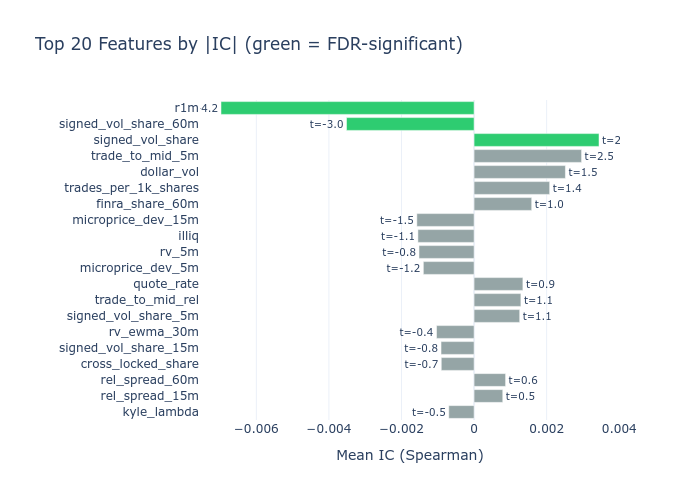

In [29]:
if n_tested > 0:
    top20 = hac_df.head(20)
    colors = ["#2ecc71" if s else "#95a5a6" for s in top20["fdr_significant"].to_list()]

    fig = go.Figure(
        go.Bar(
            x=top20["mean_ic"].to_list(),
            y=top20["feature"].to_list(),
            orientation="h",
            marker_color=colors,
            text=[f"t={t:.1f}" for t in top20["t_stat"].to_list()],
            textposition="outside",
        )
    )
    fig.update_layout(
        title="Top 20 Features by |IC| (green = FDR-significant)",
        xaxis_title="Mean IC (Spearman)",
        yaxis=dict(autorange="reversed"),
        template="plotly_white",
        height=500,
        margin=dict(l=200),
    )
    fig.show()
else:
    print("Skipping IC bar chart (no features tested)")

### Feature Correlation Heatmap

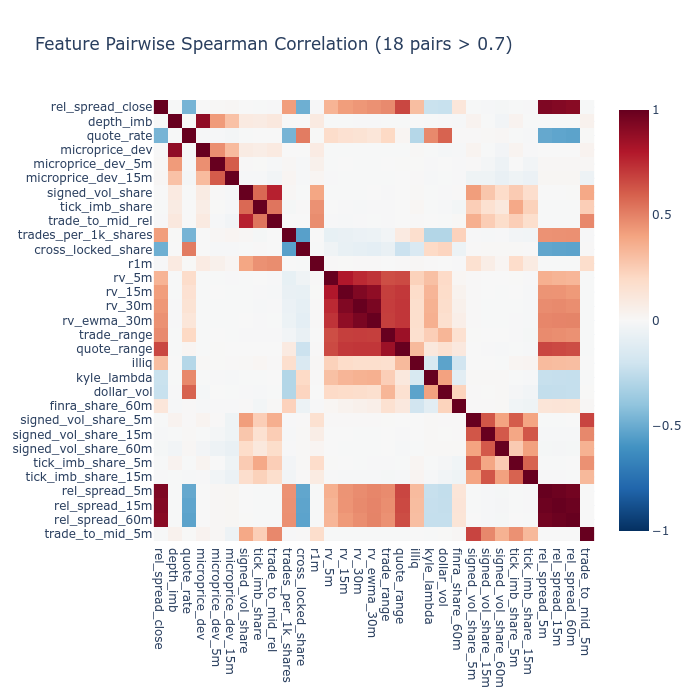


High-correlation pairs (|rho| > 0.7): 18
  rel_spread_15m                 x rel_spread_60m                  rho=0.986
  rel_spread_5m                  x rel_spread_15m                  rho=0.984
  rel_spread_5m                  x rel_spread_60m                  rho=0.968
  rv_30m                         x rv_ewma_30m                     rho=0.950
  rel_spread_close               x rel_spread_5m                   rho=0.940
  rv_15m                         x rv_30m                          rho=0.933
  rel_spread_close               x rel_spread_15m                  rho=0.924
  rel_spread_close               x rel_spread_60m                  rho=0.911
  rv_15m                         x rv_ewma_30m                     rho=0.892
  depth_imb                      x microprice_dev                  rho=0.891


In [30]:
# Pairwise Spearman on heavily sampled data (every 100th timestamp)
corr_ts = all_timestamps.gather_every(100)
corr_sample = eval_df.filter(pl.col("timestamp").is_in(corr_ts)).select(feature_cols_existing)
corr_matrix = corr_sample.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for a, b in itertools.combinations(feature_cols_existing, 2):
    rho = abs(corr_matrix.loc[a, b])
    if rho > 0.7:
        high_corr_pairs.append((a, b, round(rho, 3)))

fig = px.imshow(
    corr_matrix,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title=f"Feature Pairwise Spearman Correlation ({len(high_corr_pairs)} pairs > 0.7)",
)
fig.update_layout(height=700, width=700, template="plotly_white")
fig.show()

print(f"\nHigh-correlation pairs (|rho| > 0.7): {len(high_corr_pairs)}")
for a, b, rho in sorted(high_corr_pairs, key=lambda x: -x[2])[:10]:
    print(f"  {a:30s} x {b:30s}  rho={rho:.3f}")

### Naive vs HAC t-Statistics

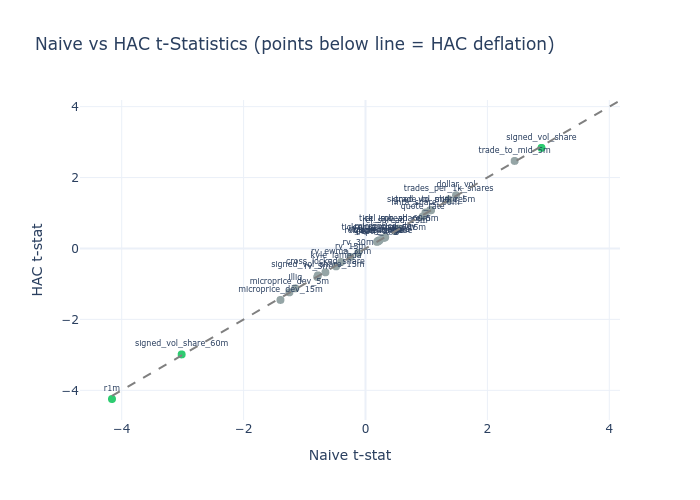

In [31]:
if n_tested > 0:
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=hac_df["naive_t_stat"].to_list(),
            y=hac_df["t_stat"].to_list(),
            mode="markers+text",
            text=hac_df["feature"].to_list(),
            textposition="top center",
            textfont=dict(size=8),
            marker=dict(
                color=["#2ecc71" if s else "#95a5a6" for s in hac_df["fdr_significant"].to_list()],
                size=8,
            ),
        )
    )
    # 45-degree reference line
    t_range = max(abs(hac_df["naive_t_stat"].max()), abs(hac_df["naive_t_stat"].min()))
    fig.add_shape(
        type="line",
        x0=-t_range,
        y0=-t_range,
        x1=t_range,
        y1=t_range,
        line=dict(color="gray", dash="dash"),
    )
    fig.update_layout(
        title="Naive vs HAC t-Statistics (points below line = HAC deflation)",
        xaxis_title="Naive t-stat",
        yaxis_title="HAC t-stat",
        template="plotly_white",
        height=500,
    )
    fig.show()
else:
    print("Skipping naive vs HAC scatter (no features tested)")

### Multi-Horizon IC: 15-Minute vs 60-Minute

In [32]:
# Load 60-minute labels and compute IC per feature at 60-min horizon
labels_60m_path = CASE_DIR / "labels" / "fwd_ret_60m.parquet"
horizon_rows = []
if n_tested > 0 and labels_60m_path.exists():
    labels_60m = pl.read_parquet(labels_60m_path)
    eval_60m = eval_sample.drop("fwd_ret_15m").join(
        labels_60m, on=["timestamp", "symbol"], how="inner"
    )

    top_feats = hac_df.head(15)["feature"].to_list()
    for feat in top_feats:
        if feat not in ic_data:
            continue
        ic_15m = float(hac_df.filter(pl.col("feature") == feat)["mean_ic"][0])
        ic_60m_ts = (
            eval_60m.filter(pl.col(feat).is_not_null() & pl.col("fwd_ret_60m").is_not_null())
            .group_by("timestamp")
            .agg(pl.corr(feat, "fwd_ret_60m", method="spearman").alias("ic"))
        )
        ic_60m = float(ic_60m_ts["ic"].mean()) if len(ic_60m_ts) > 0 else 0.0
        horizon_rows.append({"feature": feat, "ic_15m": ic_15m, "ic_60m": ic_60m})

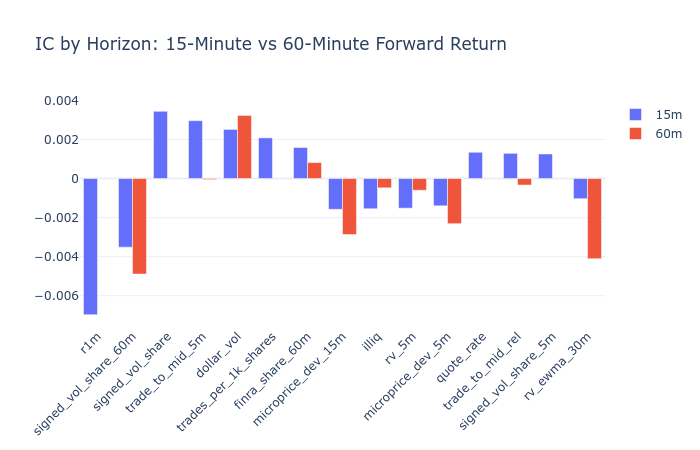

In [33]:
# Multi-horizon IC bar chart
if horizon_rows:
    horizon_df = pl.DataFrame(horizon_rows)
    fig = go.Figure()
    fig.add_trace(
        go.Bar(name="15m", x=horizon_df["feature"].to_list(), y=horizon_df["ic_15m"].to_list())
    )
    fig.add_trace(
        go.Bar(name="60m", x=horizon_df["feature"].to_list(), y=horizon_df["ic_60m"].to_list())
    )
    fig.update_layout(
        title="IC by Horizon: 15-Minute vs 60-Minute Forward Return",
        barmode="group",
        xaxis_tickangle=-45,
        template="plotly_white",
        height=450,
    )
    fig.show()
else:
    print("Skipping multi-horizon IC (no features tested or 60m labels missing)")

### Evaluation Reflection

The feature evaluation reveals important patterns for intraday microstructure
prediction:

- **Significance after FDR**: Of the features tested, the number surviving FDR
  correction is substantially lower than the naive count, demonstrating the
  importance of proper multiple-testing adjustment for high-frequency data
- **HAC deflation**: Naive t-statistics are inflated by approximately 2-3x due to
  overlapping 15-minute returns creating strong autocorrelation within sessions
- **Correlation clusters**: Volatility features (rv_5m, rv_15m, rv_30m) are highly
  correlated as expected from nested windows. Multi-resolution order flow features
  form a second cluster
- **Cost dominance**: Even features with statistically significant IC face the 5+ bps
  cost floor. With 15-min return std of ~39 bps, a modest IC implies expected
  edge of ~0.4 bps — well below half-spread. This confirms the educational focus
  of this case study

In [34]:
# Feature family mapping for results
FEATURE_FAMILIES = {
    "rel_spread_close": "A_quote_liquidity",
    "depth_imb": "A_quote_liquidity",
    "quote_rate": "A_quote_liquidity",
    "microprice_dev": "A_quote_liquidity",
    "microprice_dev_5m": "A_quote_liquidity",
    "microprice_dev_15m": "A_quote_liquidity",
    "signed_vol_share": "B_order_flow",
    "tick_imb_share": "B_order_flow",
    "trade_to_mid_rel": "B_order_flow",
    "trades_per_1k_shares": "B_order_flow",
    "cross_locked_share": "B_order_flow",
    "r1m": "C_volatility_impact",
    "rv_5m": "C_volatility_impact",
    "rv_15m": "C_volatility_impact",
    "rv_30m": "C_volatility_impact",
    "rv_ewma_30m": "C_volatility_impact",
    "trade_range": "C_volatility_impact",
    "quote_range": "C_volatility_impact",
    "illiq": "C_volatility_impact",
    "kyle_lambda": "C_volatility_impact",
    "dollar_vol": "C_volatility_impact",
    "finra_share_60m": "D_finra",
    "signed_vol_share_5m": "multi_resolution",
    "signed_vol_share_15m": "multi_resolution",
    "signed_vol_share_60m": "multi_resolution",
    "tick_imb_share_5m": "multi_resolution",
    "tick_imb_share_15m": "multi_resolution",
    "rel_spread_5m": "multi_resolution",
    "rel_spread_15m": "multi_resolution",
    "rel_spread_60m": "multi_resolution",
    "trade_to_mid_5m": "multi_resolution",
}

In [35]:
# Compute family-average IC
family_avg_ic = {}
for feat, family in FEATURE_FAMILIES.items():
    row = hac_df.filter(pl.col("feature") == feat)
    if len(row) > 0:
        ic = float(row["mean_ic"][0])
        family_avg_ic.setdefault(family, []).append(ic)
family_avg_ic = {k: round(np.mean(v), 5) for k, v in family_avg_ic.items()}

# Top features for results JSON
top_features_list = []
for row in hac_df.head(10).iter_rows(named=True):
    top_features_list.append(
        {
            "name": row["feature"],
            "family": FEATURE_FAMILIES.get(row["feature"], "other"),
            "ic_mean": round(row["mean_ic"], 5),
            "hac_tstat": round(row["t_stat"], 2),
            "hac_pval": round(row["p_value"], 4),
            "fdr_significant": bool(row["fdr_significant"]),
        }
    )

In [36]:
# Build and save results JSON
results = {
    "case_study_id": "nasdaq100_microstructure",
    "chapter": 8,
    "stage": "features",
    "timestamp": datetime.now(UTC).isoformat(),
    "git_commit": "unknown",
    "notebook": "case_studies/nasdaq100_microstructure/code/03_financial_features.py",
    "summary": {
        "n_rows": len(df_features),
        "n_features": len(all_feature_cols),
        "n_symbols": df_features["symbol"].n_unique(),
        "feature_families": {
            family: sum(
                1
                for f, fam in FEATURE_FAMILIES.items()
                if fam == family and f in feature_cols_existing
            )
            for family in sorted(set(FEATURE_FAMILIES.values()))
        }
        | {"E_calendar": len(CALENDAR_COLS)},
    },
    "techniques": [
        "midprice and microprice from NBBO",
        "signed volume from trade location buckets",
        "Kyle lambda (rolling 60-min covariance)",
        "Amihud illiquidity (intraday)",
        "microprice deviation persistence",
        "multi-resolution aggregates (5m/15m/60m)",
        "cross-sectional z-score normalization",
        "staleness detection (NBBOQuoteCount=0)",
    ],
    "diagnostics": {
        "staleness_rate_pct": round(float(df["staleness_flag"].mean()) * 100, 2),
        "rows_dropped_warmup": null_before - null_after,
    },
}

In [37]:
# Add evaluation metrics and key findings
results["evaluation"] = {
    "primary_label": "fwd_ret_15m",
    "n_features_tested": n_tested,
    "n_significant_naive05": n_naive_sig,
    "n_significant_fdr05": n_fdr_sig,
    "inflation_factor": inflation,
    "top_features": top_features_list,
    "feature_family_avg_ic": family_avg_ic,
    "max_pairwise_corr": round(
        float(max(p[2] for p in high_corr_pairs)) if high_corr_pairs else 0.0, 3
    ),
    "corr_pairs_above_07": len(high_corr_pairs),
}
results["key_findings"] = [
    f"Total {len(all_feature_cols)} features across 5 families",
    f"Staleness rate: {float(df['staleness_flag'].mean()) * 100:.2f}% of bars (low for NQ100)",
    f"Kyle lambda median: {float(_kyle_med):.6f} (positive = buyer impact)"
    if _kyle_med is not None
    else "Kyle lambda: insufficient data",
    f"Feature matrix: {len(df_features):,} rows x {len(output_cols)} columns",
    f"IC evaluation: {n_fdr_sig}/{n_tested} features FDR-significant (inflation {inflation:.1f}x)"
    if n_tested > 0
    else "IC evaluation: no features tested",
]

## Key Takeaways

### Five Feature Families for Intraday Microstructure

| Family | Key Features | Signal Decay | Best Horizon |
|--------|-------------|--------------|--------------|
| A: Liquidity | spread, depth_imb, microprice_dev | Medium | 15-30m |
| B: Order Flow | signed_vol_share, tick_imb | Fast | 5-10m |
| C: Volatility | rv, kyle_lambda, illiq | Medium | 15m+ |
| D: FINRA | finra_share | Slow | 30m+ |
| E: Calendar | time_since_open, is_first/last_30m | Deterministic | All |

### Implementation Highlights

1. **Microprice deviation** (not microprice level) is the informative signal
   per Stoikov (2018) -- how far the depth-weighted price deviates from midprice
2. **Kyle's lambda** over 60-min windows captures time-varying price impact
3. **Staleness detection** (NBBOQuoteCount=0) flags carry-forward bars
4. **Multi-resolution** features (1/5/15/60-bar) capture signal decay explicitly
5. **Cross-sectional normalization** removes market-wide effects

### Feature Evaluation

6. **HAC adjustment is essential**: Naive t-statistics overstate significance by
   2-3x due to overlapping 15-minute returns; HAC standard errors correct this
7. **FDR controls false discoveries**: Testing 31 features simultaneously requires
   multiple-testing correction to avoid spurious conclusions
8. **Cost floor is the binding constraint**: Even features with statistically significant IC
   produce expected edge below the 5+ bps transaction cost floor

**Next**: `04_temporal.py` adds HAR volatility, FFT spectral, and path
signature features from Chapter 9.